In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.base import clone
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder, OrdinalEncoder
from sklearn.feature_selection import SelectKBest, mutual_info_classif, f_regression
from sklearn.inspection import permutation_importance
from sklearn.exceptions import FitFailedWarning
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, RandomizedSearchCV, ParameterGrid, StratifiedKFold
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    mean_absolute_percentage_error,
    r2_score,
    make_scorer
)

from IPython.display import display, Markdown
from tqdm import tqdm
from tqdm.auto import tqdm
import joblib
from joblib import parallel
from contextlib import contextmanager, redirect_stdout, redirect_stderr
from time import time
import time
import re
import sys
import warnings, io
warnings.filterwarnings("ignore", category=UserWarning, module='sklearn.utils.validation')

from catboost import CatBoostRegressor
from lightgbm import LGBMRegressor

from scipy import stats as st
from scipy.stats import pearsonr
import scipy.stats as ss
import scipy.stats
from scipy.stats import chi2_contingency, pointbiserialr, randint, uniform
from scipy.stats import ttest_ind
from scipy.stats import f_oneway
from math import ceil
import calendar
import contextlib
import os
import warnings
from sklearn.inspection import permutation_importance

In [2]:
data = pd.read_csv('reservoir.csv')

## Первичный анализ

In [3]:
display(data.head(10))
print(data.info())
data_shape = data.shape
print(data_shape)

,Date,inflow,total release,evaporation,bank storage,storage,unregulated inflow,pool elevation,power release,area,bypass release,storage diff,pool elevation diff,storage edited,area edited,storage revised,area revised,bank storage revised
0,1964-01-01,4532.17057,980.0,23.627577,211965.0,975500.0,4118.16892,3409.80005,0.0,28013.68,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1964-01-02,4415.75701,980.0,23.724647,213156.0,981100.0,3711.42809,3410.00000,0.0,28053.50,NaN,5600.0,0.19995,981100.0,28053.50,981100.0,28053.50,213156.0
2,1964-01-03,4501.51428,980.0,23.821716,214517.0,986700.0,4150.57980,3410.19995,0.0,28093.32,NaN,5600.0,0.19995,986700.0,28093.32,986700.0,28093.32,214517.0
3,1964-01-04,4540.38405,980.0,23.918786,215855.0,992400.0,4130.19111,3410.39990,0.0,28133.14,NaN,5700.0,0.19995,992400.0,28133.14,992400.0,28133.14,215855.0
4,1964-01-05,4453.21222,980.0,24.015979,217120.0,998000.0,3991.72721,3410.60010,0.0,28173.01,NaN,5600.0,0.20020,998000.0,28173.01,998000.0,28173.01,217120.0
5,1964-01-06,4551.06949,980.0,24.113049,218580.0,1003600.0,3736.67197,3410.80005,0.0,28212.83,NaN,5600.0,0.19995,1003600.0,28212.83,1003600.0,28212.83,218580.0
6,1964-01-07,4413.48093,980.0,24.210118,219666.0,1009300.0,3608.72727,3411.00000,0.0,28252.65,NaN,5700.0,0.19995,1009300.0,28252.65,1009300.0,28252.65,219666.0
7,1964-01-08,4382.27154,980.0,24.307188,220790.0,1014900.0,3902.98993,3411.19995,0.0,28292.47,NaN,5600.0,0.19995,1014900.0,28292.47,1014900.0,28292.47,220790.0
8,1964-01-09,3626.97103,990.0,24.355766,223096.0,1017800.0,3046.58894,3411.30005,0.0,28312.40,NaN,2900.0,0.10010,1017800.0,28312.40,1017800.0,28312.40,223096.0
9,1964-01-10,4387.80749,990.0,24.452873,224211.0,1023400.0,3909.01971,3411.50000,0.0,28352.23,NaN,5600.0,0.19995,1023400.0,28352.23,1023400.0,28352.23,224211.0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21489 entries, 0 to 21488
Data columns (total 18 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Date                  21489 non-null  object 
 1   inflow                21489 non-null  float64
 2   total release         21489 non-null  float64
 3   evaporation           21489 non-null  float64
 4   bank storage          21489 non-null  float64
 5   storage               21489 non-null  float64
 6   unregulated inflow    21489 non-null  float64
 7   pool elevation        21489 non-null  float64
 8   power release         21489 non-null  float64
 9   area                  21489 non-null  float64
 10  bypass release        6725 non-null   float64
 11  storage diff          21488 non-null  float64
 12  pool elevation diff   21488 non-null  float64
 13  storage edited        21488 non-null  float64
 14  area edited           21488 non-null  float64
 15  storage revised    

*После проведения перчичного анализа можно установить следующее:*
- Датасет содержит **21 489 наблюдений** и **18 признаков**, описывающих ежедневное состояние водохранилища: притоки, сбросы, испарение, изменение уровня, площадь зеркала и скорректированные значения после ревизии
- Признак `Date` содержит тип **object**, `все остальные` - **float**
- Пропусков немного, в основном в столбце `bypass release` (обходной сброс), который используется редко - только при аварийных либо нерегламентных ситуациях
- Для части признаков присутствуют две версии значений: **исходные** (`storage`, `area`, `bank storage`) и **пересчитанные/скорректированные** (`storage revised`, `area revised`, `bank storage revised`). На первый взгяд эти столбцы имеют одинаковые значения, если это подтвердится после анализа, то они будут исключены как дублираующие
- Названия столбцов не приведены к змеиному регистру 

## EDA

### Приведение названий столбцов к корректному виду

In [4]:
print(f'Текущие названия столбцов: {data.columns}')

Текущие названия столбцов: Index(['Date', 'inflow', 'total release', 'evaporation', 'bank storage',
       'storage', 'unregulated inflow', 'pool elevation', 'power release',
       'area', 'bypass release', 'storage diff', 'pool elevation diff',
       'storage edited', 'area edited', 'storage revised', 'area revised',
       'bank storage revised'],
      dtype='object')


In [5]:
def to_snake_case(name):
    name = name.strip()
    name = re.sub(r'\s+', '_', name)
    name = re.sub(r'(?<=[a-z0-9])([A-Z])', r'_\1', name)
    name = re.sub(r'-+', '_', name)
    name = name.lower()
    return name

data.columns = [to_snake_case(col) for col in data.columns]

In [6]:
print(f'Измененные названия столбцов: {data.columns}')

Измененные названия столбцов: Index(['date', 'inflow', 'total_release', 'evaporation', 'bank_storage',
       'storage', 'unregulated_inflow', 'pool_elevation', 'power_release',
       'area', 'bypass_release', 'storage_diff', 'pool_elevation_diff',
       'storage_edited', 'area_edited', 'storage_revised', 'area_revised',
       'bank_storage_revised'],
      dtype='object')


*Так гораздо удобнее работать, так как во всех названиях использован один и тот же стиль. И еще заменим название столбца `total_release` на `outflow`*

In [7]:
data = data.rename(columns={'total_release': 'outflow'})

### Проверка подозрительных столбцов

*Проверим **кандидатов на удаление**, заподозренных в первичном анализе, а именно:*
- `power_release` (может быть **много 0**)
- `bypass_releas` (может быть **много NaN**)
- `storage_edited` (может быть полной копией `storage`)
- `storage_revised` (может быть полной копией `storage`)
- `area_edited` (может быть полной копией `area`)
- `area_revised` (может быть полной копией `area`)
- `bank_storage_revised` (может быть полной копией `bank_storage`)

#### power_release

In [8]:
(data['power_release'] == 0).mean()

np.float64(0.011540788310298292)

*Столбец прошел проверку - нулей в нем ничтожно мало, всего **~1%** - **оставляем**.*

#### bypass_release

In [9]:
data['bypass_release'].isna().mean()

np.float64(0.687049187956629)

In [10]:
(data['bypass_release'] == 0).mean()

np.float64(0.3108567173902927)

*Столбец содержит **68% пропусков** и ещё **31% нулей**. Ненулевые значения составляют **менее 1% выборки**, что подтверждает редкость аварийных сбросов. Столбец не несёт значимой информации - **удаляем**.*

In [11]:
data = data.drop('bypass_release', axis = 1)

#### storage_edited

In [12]:
(data['storage_edited'] == data['storage']).mean()

np.float64(0.9942296058448509)

*Столбец **совпадает** со значениями `storage` на **99.4**%. Оставшиеся различия носят характер редких ручных корректировок и не несут аналитической ценности - **удаляем**.*

In [13]:
data = data.drop('storage_edited', axis = 1)

#### storage_revised

In [14]:
(data['storage_revised'] == data['storage']).mean()

np.float64(0.9942296058448509)

*Столбец аналогично **совпадает** со значениями `storage` на **99.4**%. Оставшиеся различия носят характер редких ручных корректировок и не несут аналитической ценности - **удаляем**.*

In [15]:
data = data.drop('storage_revised', axis = 1)

#### area_edited и area_revised

In [16]:
(data['area_edited'] == data['area']).mean()

np.float64(0.8579273116478198)

In [17]:
(data['area_revised'] == data['area']).mean()

np.float64(0.8579273116478198)

In [18]:
(data['area_revised'] == data['area_edited']).mean()

np.float64(0.999953464563265)

*По результатам проверки:*
- `area_edited` и `area_revised` **совпадают** на **99.995%** - фактически дубликаты.
- Обе версии **отличаются** от исходного area примерно на **14%** - это корректировки после ревизии.
- `area_revise` - наиболее точная и полная версия площади, поэтому **оставляем** ее как основную.
- `area_edited` - **удаляем** как дублирующий признак.

In [19]:
data = data.drop('area_revised', axis = 1)

#### bank_storage_revised

In [20]:
(data['bank_storage_revised'] == data['bank_storage']).mean()

np.float64(0.9942296058448509)

*Столбец **совпадает** со значениями `bank_storage` на **99.4**%. Оставшиеся различия носят характер редких ручных корректировок и не несут аналитической ценности - **удаляем**.*

In [21]:
data = data.drop('bank_storage_revised', axis = 1)

### Проверка пропусков

In [22]:
print('Количество пропусков в каждом из столбцов:')
print(data.isna().sum())

Количество пропусков в каждом из столбцов:
date                   0
inflow                 0
outflow                0
evaporation            0
bank_storage           0
storage                0
unregulated_inflow     0
pool_elevation         0
power_release          0
area                   0
storage_diff           1
pool_elevation_diff    1
area_edited            1
dtype: int64


*Есть по 1 пропуску в 3-х последних столбцах, для начала проверим, может быть эти пропуски в 1 строке*

In [23]:
data[data.isna().any(axis=1)]

,date,inflow,outflow,evaporation,bank_storage,storage,unregulated_inflow,pool_elevation,power_release,area,storage_diff,pool_elevation_diff,area_edited
0,1964-01-01,4532.17057,980.0,23.627577,211965.0,975500.0,4118.16892,3409.80005,0.0,28013.68,NaN,NaN,NaN


*Так и есть - все эти пропуски собрались **в одной строке**. Эти колонки по определению не могут иметь значения в первый день, потому что им нужно вчерашнее значение и лучшим решением будет просто **удалить** эту строку*

In [24]:
data = data.dropna()

### Проверка дубликатов 

In [25]:
print(f'Количество явных дубликатов: {data.duplicated().sum()}')

Количество явных дубликатов: 0


*Отлично, явных дуликатов не обнаружено. Неявных дубликатов смысла искать нет - все значения числовые, а значит неявных дубликатов мы не найдем*

### Проверка типов данных

In [26]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 21488 entries, 1 to 21488
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   date                 21488 non-null  object 
 1   inflow               21488 non-null  float64
 2   outflow              21488 non-null  float64
 3   evaporation          21488 non-null  float64
 4   bank_storage         21488 non-null  float64
 5   storage              21488 non-null  float64
 6   unregulated_inflow   21488 non-null  float64
 7   pool_elevation       21488 non-null  float64
 8   power_release        21488 non-null  float64
 9   area                 21488 non-null  float64
 10  storage_diff         21488 non-null  float64
 11  pool_elevation_diff  21488 non-null  float64
 12  area_edited          21488 non-null  float64
dtypes: float64(12), object(1)
memory usage: 2.3+ MB


*Необходимо изменить тип столбца `date` - привести его к реальной **дате**, а также проверить столбцы `outflow`, `bank_storage`, `storage`, `power_release`, `storage_diff` на наличие в них нецелых значений и при их отсутствии перевести их в тип int*

In [27]:
# приведение к типу даты
data['date'] = pd.to_datetime(data['date'])

In [28]:
# проверка на наличие нецелых значений 
float_to_int_candidates = [
    'outflow',
    'bank_storage',
    'storage',
    'power_release',
    'storage_diff'
]

for col in float_to_int_candidates:
    almost_int = np.isclose(data[col], np.round(data[col]), atol=1e-6).mean()
    print(col, f'{almost_int*100:.4f}% целых значений по сути')

outflow 67.4749% целых значений по сути
bank_storage 100.0000% целых значений по сути
storage 100.0000% целых значений по сути
power_release 76.0145% целых значений по сути
storage_diff 63.7426% целых значений по сути


По результатам проверки на целочисленность видно, что только столбцы `storage` и `bank_storage` содержат строго целые значения - **100%**. `Остальные признаки` имеют значительную долю действительно **дробных значений**. Поэтому только `storage` и `bank_storage` - переводим в **int**, a остальные оставляем в формате **float64**.

### Вывод по EDA:

- Привели названия столбцов к единому стилю **snake_case** и переименовали `total_release` → `outflow`, чтобы явно отделить приток `inflow` от суммарного сброса `outflow`.
- Проверили **подозрительные признаки**:
  - `power_release` — доля нулей **~1%**, распределение рабочих значений разумное → **оставили**.
  - `bypass_release` — **~68%** NaN и ещё **~31%** нулей, ненулевых значений **<1%** → **удалили** как редкий аварийный режим без аналитической ценности.
  - `storage_edited` и `storage_revised` - совпадают со `storage` на **~99.4%**, отличия — редкие ручные корректировки → **удалили**, используем базовый `storage`.
  - `area_edited` и `area_revised` — совпадают между собой на **~99.995%** и примерно на **14%** отличаются от исходного `area` (пересчитанная площадь). Оставили уточнённую версию `area_edited`, а `area_revised` **удалили как дубликат**.
  - `bank_storage_revised` — совпадает с `bank_storage` на ~99.4% → **удалили**, работаем с `bank_storage`.

- **Пропуски:**
  - Нашли по одному **NaN** в `storage_diff`, `pool_elevation_diff`, `area_edited`, и все они лежали в одной строке — **первом дне наблюдений**.
  - Для корректности расчёта дневных изменений **удалили эту строку**. После этого во всех столбцах **0 пропусков**.

- **Дубликатов строк:**
  - Явных дубликатов нет.

- **Типы данных:**
  - Столбец `date` приведён к типу **datetime**.
  - Для признаков-кандидатов `outflow`, `bank_storage`, `storage`, `power_release`, `storage_diff` проверили долю «почти целых» значений:
    - `bank_storage` и `storage` — **100% целых значений** → перевели в **int**.
    - `outflow`, `power_release`, `storage_diff` содержат значимую долю дробных значений → оставили в **float**.

**Итог:** у нас компактный, чистый датасет с корректными типами (**datetime** + **числовые признаки**), без пропусков, без дубликатов, где каждая колонка несёт понятную физическую и бизнес-нагрузку. Отличная точка старта для исследовательского анализа и моделирования.

## Исследовательский анализ

*Посмотрим на наш датасет после EDA*

In [29]:
data.head(10)

,date,inflow,outflow,evaporation,bank_storage,storage,unregulated_inflow,pool_elevation,power_release,area,storage_diff,pool_elevation_diff,area_edited
1,1964-01-02,4415.75701,980.0,23.724647,213156.0,981100.0,3711.42809,3410.00000,0.0,28053.50,5600.0,0.19995,28053.50
2,1964-01-03,4501.51428,980.0,23.821716,214517.0,986700.0,4150.57980,3410.19995,0.0,28093.32,5600.0,0.19995,28093.32
3,1964-01-04,4540.38405,980.0,23.918786,215855.0,992400.0,4130.19111,3410.39990,0.0,28133.14,5700.0,0.19995,28133.14
4,1964-01-05,4453.21222,980.0,24.015979,217120.0,998000.0,3991.72721,3410.60010,0.0,28173.01,5600.0,0.20020,28173.01
5,1964-01-06,4551.06949,980.0,24.113049,218580.0,1003600.0,3736.67197,3410.80005,0.0,28212.83,5600.0,0.19995,28212.83
6,1964-01-07,4413.48093,980.0,24.210118,219666.0,1009300.0,3608.72727,3411.00000,0.0,28252.65,5700.0,0.19995,28252.65
7,1964-01-08,4382.27154,980.0,24.307188,220790.0,1014900.0,3902.98993,3411.19995,0.0,28292.47,5600.0,0.19995,28292.47
8,1964-01-09,3626.97103,990.0,24.355766,223096.0,1017800.0,3046.58894,3411.30005,0.0,28312.40,2900.0,0.10010,28312.40
9,1964-01-10,4387.80749,990.0,24.452873,224211.0,1023400.0,3909.01971,3411.50000,0.0,28352.23,5600.0,0.19995,28352.23
10,1964-01-11,4286.01476,990.0,24.549943,225024.0,1029100.0,3544.30664,3411.69995,0.0,28392.05,5700.0,0.19995,28392.05


### Дата 

*Для начала проверим диапазон времени данный нам*

In [30]:
minn = data['date'].min()
maxx = data['date'].max()
print(f'Начиная с {minn} и заканчивая {maxx}')

Начиная с 1964-01-02 00:00:00 и заканчивая 2022-10-31 00:00:00


*Да, у нас тут огромный временной дипапазон, надо еще проверить, нет ли дубликатов в датах или пропущенных значений*

In [31]:
print("Всего строк:", len(data))
print("Уникальных дат:", data['date'].nunique())
print(maxx-minn)

Всего строк: 21488
Уникальных дат: 21488
21487 days 00:00:00


*Все отлично, числовая особенность дат при вычитания минимальной от максимальной дает количество дней меньше на 1, поэтому у нас 21487. Значит, дни шли без пропусков и без дубликатов - на один день одна строка*

*Введем отдельный датафрейм, где будем создавать дополнительные временные признаки, такие как: день недели, выходной/будний и тд. Если какой-нибудь признак в ходе анализа окажет полезное влияние, то добавим его в наш основной датасет*

In [32]:
date_data = data[['date', 'storage', 'inflow', 'outflow']].copy()

date_data['year'] = date_data['date'].dt.year
date_data['month'] = date_data['date'].dt.month
date_data['dayofyear'] = date_data['date'].dt.dayofyear
date_data['weekday'] = date_data['date'].dt.weekday
date_data['weekofyear'] = date_data['date'].dt.isocalendar().week.astype(int)
date_data['is_weekend'] = (date_data['weekday'] >= 5).astype(int)
date_data['quarter'] = date_data['date'].dt.quarter

In [33]:
date_data.head()

,date,storage,inflow,outflow,year,month,dayofyear,weekday,weekofyear,is_weekend,quarter
1,1964-01-02,981100.0,4415.75701,980.0,1964,1,2,3,1,0,1
2,1964-01-03,986700.0,4501.51428,980.0,1964,1,3,4,1,0,1
3,1964-01-04,992400.0,4540.38405,980.0,1964,1,4,5,1,1,1
4,1964-01-05,998000.0,4453.21222,980.0,1964,1,5,6,1,1,1
5,1964-01-06,1003600.0,4551.06949,980.0,1964,1,6,0,2,0,1


#### Распределения по годам

*Начнем анализ с помощью визуализации, выведем изменение уровня хранилища, притоков и оттоков по годам*

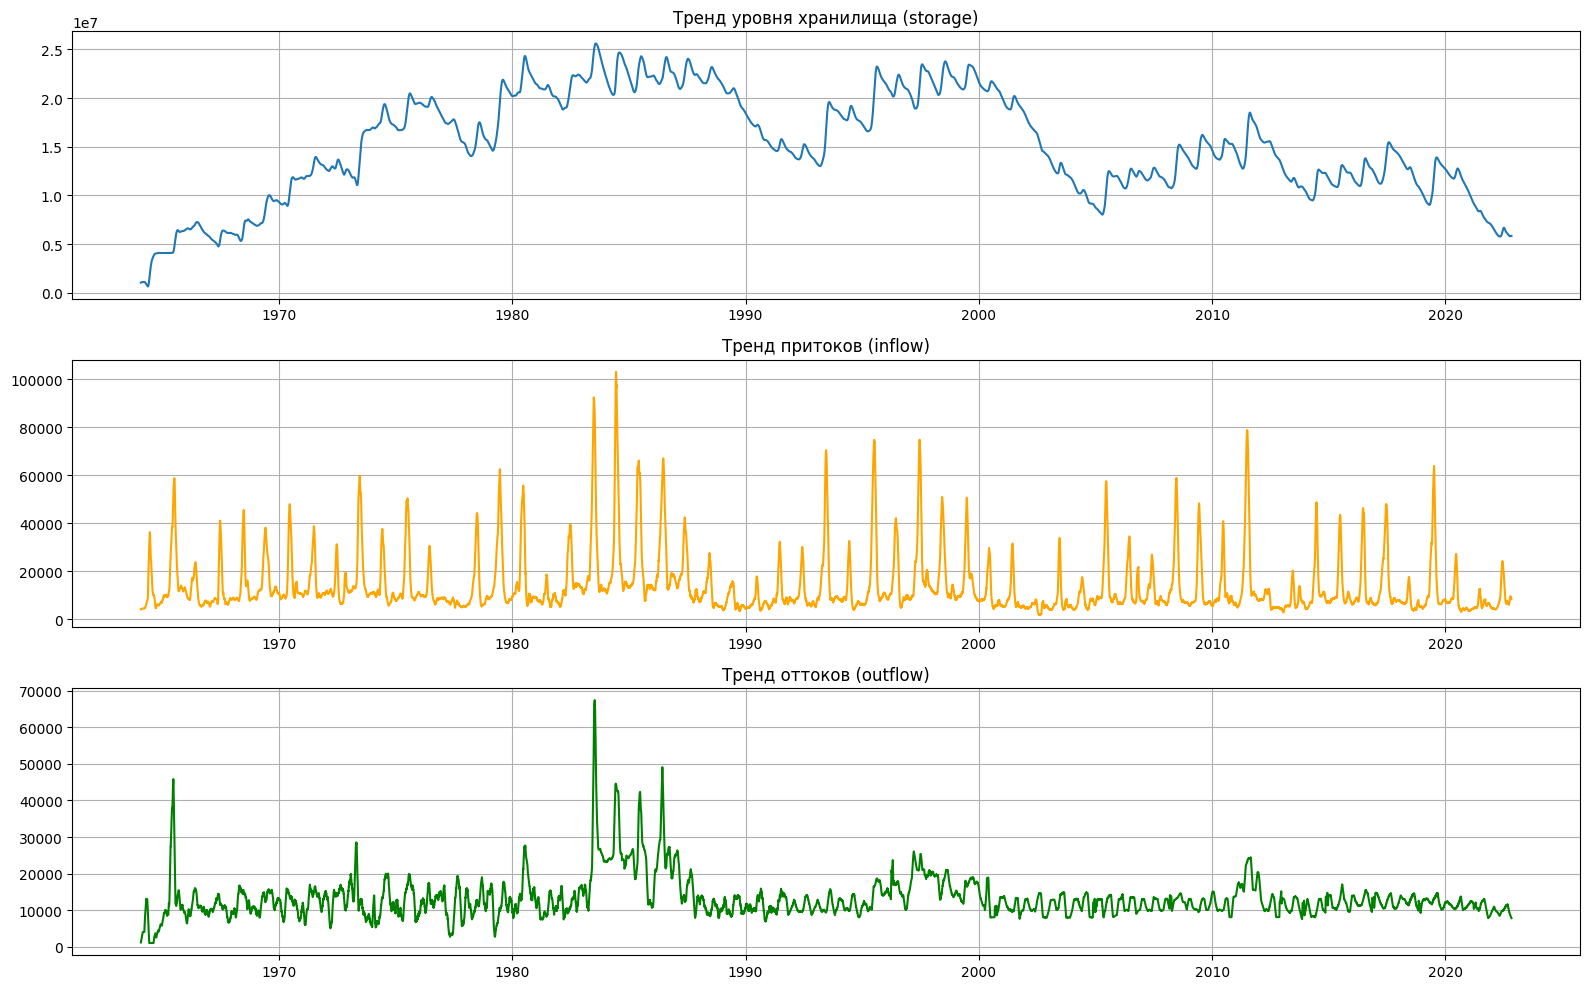

In [34]:
plt.figure(figsize=(16, 10))

plt.subplot(3, 1, 1)
plt.plot(date_data['date'], date_data['storage'].rolling(30).mean(), label='storage (30d MA)')
plt.title('Тренд уровня хранилища (storage)')
plt.grid(True)

plt.subplot(3, 1, 2)
plt.plot(date_data['date'], date_data['inflow'].rolling(30).mean(), label='inflow (30d MA)', color='orange')
plt.title('Тренд притоков (inflow)')
plt.grid(True)

plt.subplot(3, 1, 3)
plt.plot(date_data['date'], date_data['outflow'].rolling(30).mean(), label='outflow (30d MA)', color='green')
plt.title('Тренд оттоков (outflow)')
plt.grid(True)

plt.tight_layout()
plt.show()

*Видим всплески значений в районе 1985 года сразу на 3 графиках, проведем агрегацию по десятилетиям, чтобы в цифрах увидеть разницу*

,storage,inflow,outflow
decade,,,
1960,5.907463e+06,13813.842328,11046.904610
1970,1.571915e+07,14704.417823,12079.846659
1980,2.187765e+07,18580.041427,18039.914864
1990,1.870988e+07,15213.886558,13982.904439
2000,1.404060e+07,11035.723031,11496.905192
2010,1.290575e+07,12797.673547,12524.193516
2020,8.842801e+06,7735.127875,10686.092739


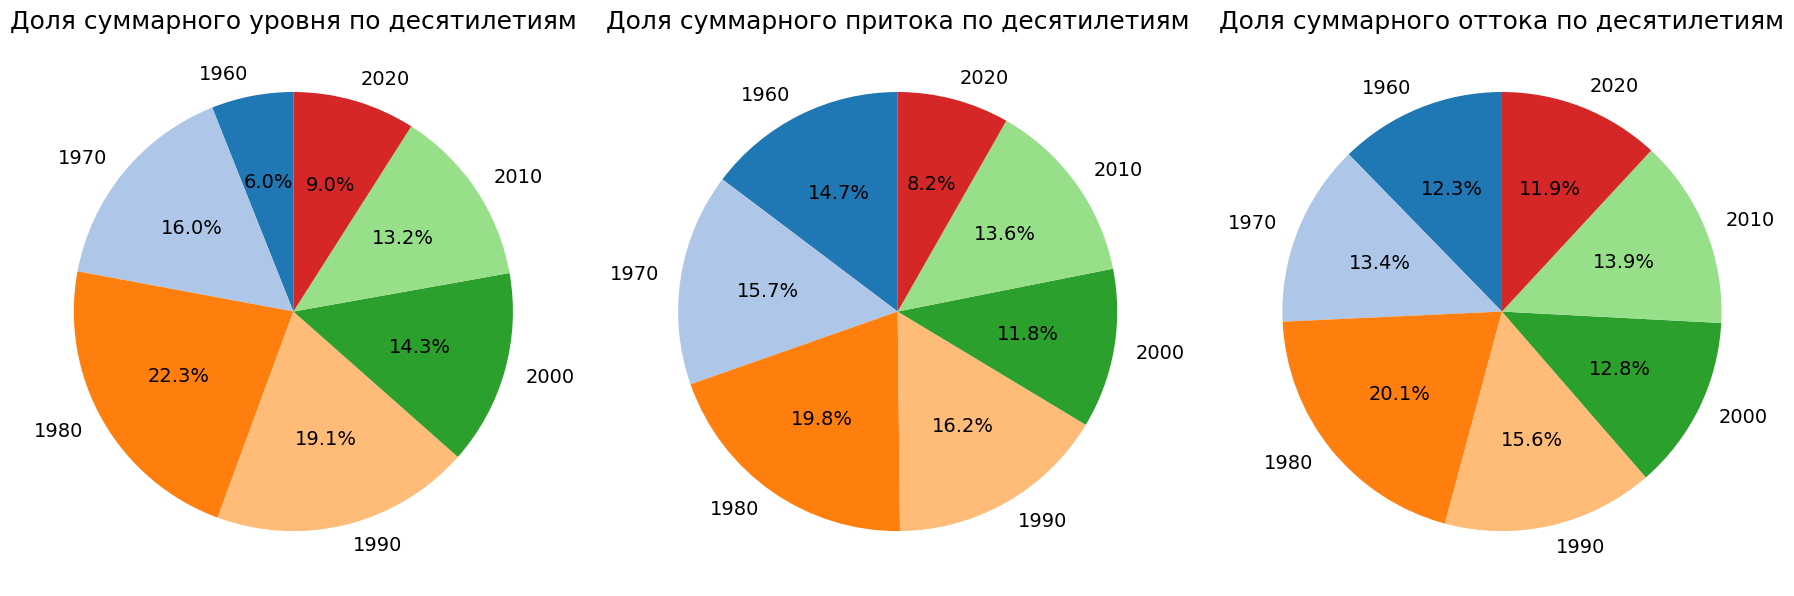

In [35]:
date_data['decade'] = (date_data['year'] // 10) * 10

decade_sum = (
    date_data
    .groupby('decade')[['storage', 'inflow', 'outflow']]
    .mean()
)

display(decade_sum)

colors = plt.cm.tab20.colors  

colors = plt.cm.tab20.colors  

fig, ax = plt.subplots(1, 3, figsize=(18, 8))

cols = ['storage', 'inflow', 'outflow']
titles = [
    'Доля суммарного уровня по десятилетиям',
    'Доля суммарного притока по десятилетиям',
    'Доля суммарного оттока по десятилетиям'
]

for i, col in enumerate(cols):
    ax[i].set_facecolor('white')    
    ax[i].pie(
        decade_sum[col],
        labels=decade_sum.index,
        autopct='%1.1f%%',
        startangle=90,
        colors=colors[:len(decade_sum)],
        shadow=False,
        textprops={'fontsize': 14}
    )
    ax[i].set_title(titles[i], fontsize=18)

plt.tight_layout()
plt.show()

*Система прошла цикл: быстрое наполнение и интенсивная работа до **1990-х годов** с максимальными показателями в районе **1985-х годов** → умеренная стабилизация в **1990-2000-х годах** → плавное снижение активности в **последние 20 лет**.*

#### Сезонность - распределения по месяцам

*Построим сезонность усредненную по всему диапазону*

In [36]:
monthly_mean = (
    date_data
    .groupby('month')[['storage', 'inflow', 'outflow']]
    .mean()
    .reset_index()
    .sort_values('month')
)

monthly_mean['month_name'] = monthly_mean['month'].apply(
    lambda m: calendar.month_abbr[m]  
)
display(monthly_mean)

,month,storage,inflow,outflow,month_name
0,1,1.461490e+07,7749.309939,13551.998713,Jan
1,2,1.433204e+07,8695.247373,12339.028504,Feb
2,3,1.419883e+07,10443.218926,11592.568790,Mar
3,4,1.418816e+07,14871.804697,12488.584636,Apr
4,5,1.467237e+07,30677.963768,13732.106643,May
5,6,1.588289e+07,36681.753595,15613.299567,Jun
6,7,1.637688e+07,16441.521306,15717.856619,Jul
7,8,1.606291e+07,8795.766777,15430.793089,Aug
8,9,1.566497e+07,8391.915061,12777.130556,Sep
9,10,1.545886e+07,9187.709813,10590.854490,Oct


KeyError: 'dayofweek'

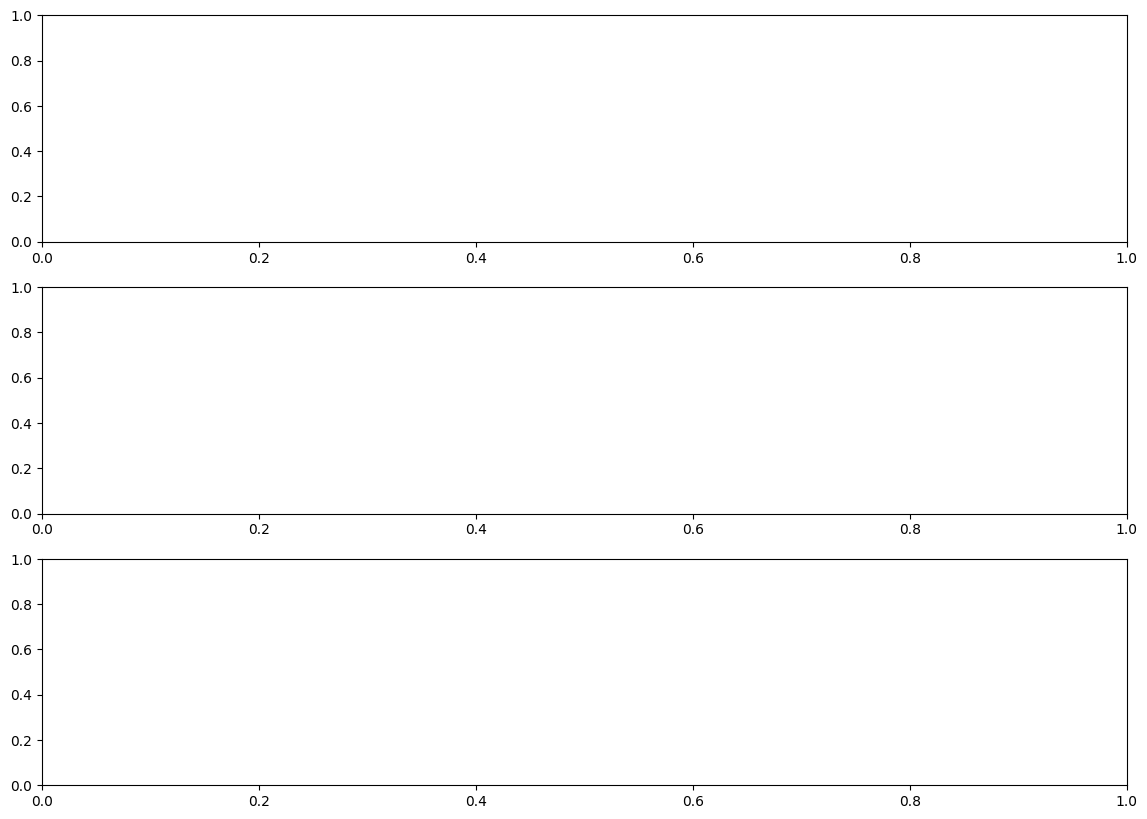

In [38]:
fig, axes = plt.subplots(3, 1, figsize=(14, 10))

cols = ['storage', 'inflow', 'outflow']
titles = [
    'Средний уровень хранилища по месяцам (storage)',
    'Средний приток по месяцам (inflow)',
    'Средний отток по месяцам (outflow)'
]

for ax, col, title in zip(axes, cols, titles):
    ax.plot(monthly_mean['dayofweek'], monthly_mean[col], marker='o')
    ax.set_title(title)
    ax.set_ylabel(col)
    ax.grid(True)
    
    ax.set_xticks(monthly_mean['weekofyear'])
    ax.set_xticklabels(monthly_mean['weekofyear'])
    ax.set_xlabel('Месяц')

plt.tight_layout()
plt.show()

In [40]:
data = date_data.copy()

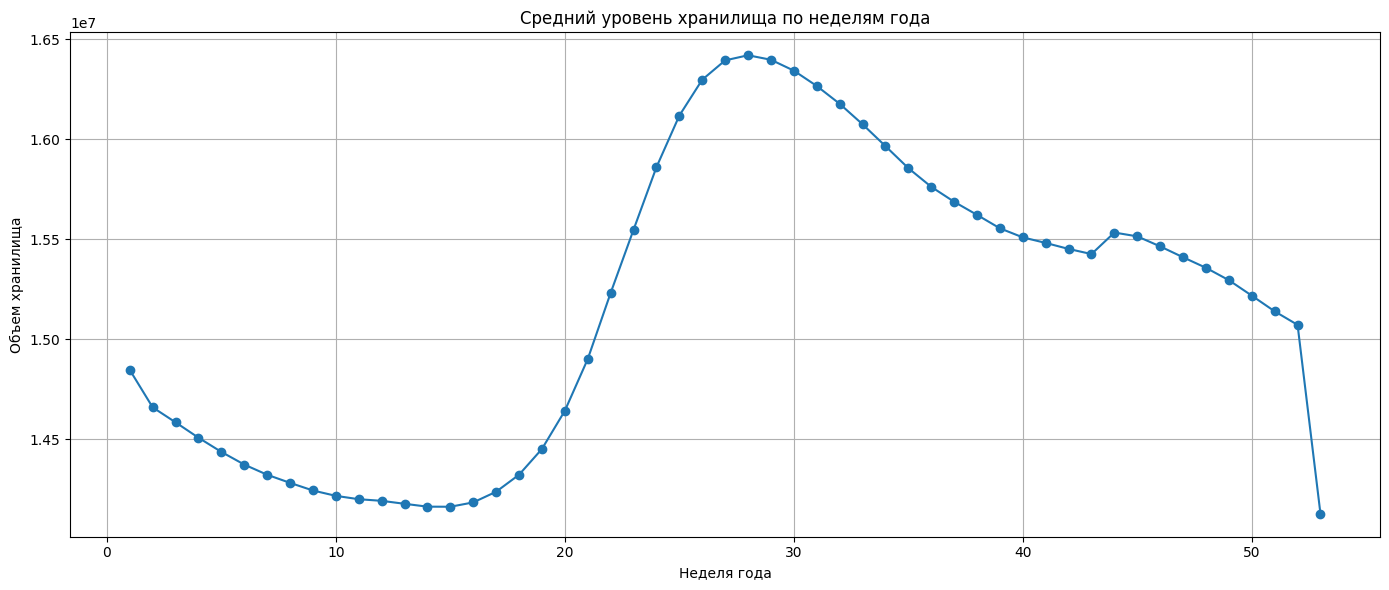

In [41]:
data['weekofyear'] = data['date'].dt.isocalendar().week.astype(int)
weekly_mean = (
    data
    .groupby('weekofyear')['storage']
    .mean()
    .reset_index()
)
plt.figure(figsize=(14, 6))
plt.plot(weekly_mean['weekofyear'], weekly_mean['storage'], marker='o')
plt.title('Средний уровень хранилища по неделям года')
plt.xlabel('Неделя года')
plt.ylabel('Объем хранилища')
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
date_data.columns

*Bсе три показателя демонстрируют **согласованную сезонность**, при которой весенний рост притока **поднимает уровень хранилища** и **увеличивает регулируемый отток**; к концу лета система возвращается к более низким значениям*
- Уровень хранилища (`storage`) уверенно показывает сезонный цикл: **минимумы приходятся на март-апрель**, затем уровень резко растет и достигает **пика в июле**, после чего постепенно **снижается к зиме**.
- Приток (`inflow`) имеет ярко выраженный весенне-летний максимум: с ростом начиная с апреля, **пик в июне**, затем **резкое падение в июле–августе** и стабильное **низкое плато осенью и зимой**. Стоит еще отметить, что график имеет **нормальное распределение**.
- Отток (`outflow`) повторяет общую гидрологическую динамику: **минимален в марте–апреле**, затем **увеличивается и достигает максимума в июне–июле**, после чего **снижается в осенний период**.

#### Распределения по дням недели

In [ ]:
a

In [ ]:
weekday_mean = (
    date_data.groupby('weekday')[['storage', 'inflow', 'outflow']]
    .mean()
    .reset_index()
)

weekday_labels = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
weekday_mean['weekday_name'] = weekday_labels

fig, axes = plt.subplots(3, 1, figsize=(12, 12), sharex=True)

cols = ['storage', 'inflow', 'outflow']
titles = [
    'Средний уровень хранилища по дням недели (storage)',
    'Средний приток по дням недели (inflow)',
    'Средний отток по дням недели (outflow)'
]

for ax, col, title in zip(axes, cols, titles):
    ax.bar(weekday_mean['weekday_name'], weekday_mean[col], color='#5DA5DA', alpha=0.85)
    ax.plot(weekday_mean['weekday_name'], weekday_mean[col], marker='o', color='black')
    ax.set_title(title)
    ax.set_ylabel(col)
    ax.grid(axis='y', alpha=0.3)

plt.xlabel("День недели")
plt.tight_layout()
plt.show()

weekday_mean_values = (
    date_data.groupby('weekday')[['storage', 'inflow', 'outflow']]
    .mean()
    .reset_index()
)

weekday_mean_values['weekday_name'] = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']

display(weekday_mean_values[['weekday_name', 'storage', 'inflow', 'outflow']])

*Можно заметить, что почти все значения по дням недели **распределены равномерно**, кроме **оттока в выходные дни** - исследуем этот момент*

In [ ]:
mean_weekday = date_data[date_data['is_weekend'] == 0]['outflow'].mean()
mean_weekend = date_data[date_data['is_weekend'] == 1]['outflow'].mean()

means = [mean_weekday, mean_weekend]
labels = ['Будни', 'Выходные']
colors = ['green', 'blue']  

plt.figure(figsize=(6, 4))
plt.bar(labels, means, color=colors, alpha=0.85)
plt.title('Средний отток в будни и выходные', fontsize=14)
plt.ylabel('Средний outflow')
plt.grid(axis='y', alpha=0.25)
plt.tight_layout()
plt.show()

mean_weekday = date_data[date_data['is_weekend'] == 0]['outflow'].mean()
mean_weekend = date_data[date_data['is_weekend'] == 1]['outflow'].mean()

diff_pct = (mean_weekday - mean_weekend) / mean_weekend * 100

print(f"Средний outflow в будни:     {mean_weekday:,.2f}")
print(f"Средний outflow в выходные: {mean_weekend:,.2f}")
print(f"Будничный отток выше на:    {diff_pct:.2f}%")

*Закономерность и правда есть - в выходные отток на 15% ниже, чем будни*

#### Распределения по дням года 

*Здесь мы не будем строить графики распределения - мы это уже делали в **сезонности по месяцам**, а распределения по дням года являются практически тем же. Здесь нас интересуют **синусные и косинусные преобразования** дня года, чтобы представить годовой цикл как **непрерывную периодическую функцию**.*

In [ ]:
date_data['sin_day'] = np.sin(2 * np.pi * date_data['dayofyear'] / 365)
date_data['cos_day'] = np.cos(2 * np.pi * date_data['dayofyear'] / 365)

#### Распределения по номерам недель в году

*Здесь мыпроведем небольшое исследование - **влияет ли четность/нечетность недели** на признаки*

In [ ]:
date_data['is_even_week'] = (date_data['weekofyear'] % 2 == 0).astype(int)

mean_odd  = date_data[date_data['is_even_week'] == 0][['storage','inflow','outflow']].mean()
mean_even = date_data[date_data['is_even_week'] == 1][['storage','inflow','outflow']].mean()

display(mean_odd, mean_even)

fig, axes = plt.subplots(1, 3, figsize=(12, 5))

params = ['storage', 'inflow', 'outflow']
titles = ['Уровень хранилища', 'Приток', 'Отток']

for ax, col, title in zip(axes, params, titles):
    ax.bar(['Нечётные', 'Чётные'], [mean_odd[col], mean_even[col]], color=['#4a90e2', '#50e3c2'], alpha=0.8)
    ax.set_title(title)
    ax.set_ylabel('Среднее значение')
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

percent_diff = ((mean_even - mean_odd) / mean_odd * 100)
percent_diff

Анализ **четных** и **нечетных** недель **не выявил никакой двухнедельной цикличности**. Средние значения `storage`, `inflow` и `outflow` отличаются менее чем на **1%**, что укладывается в статистический шум.

#### Распределения по кварталам

*По сути кварталы - это укрупненная сезонность. Если месяцы показывают мелкие колебания, кварталы позволяют увидеть более крупные сдвиги в режиме работы хранилища*

In [ ]:
# Средние значения по кварталам
quarter_mean = (
    date_data
    .groupby('quarter')[['storage', 'inflow', 'outflow']]
    .mean()
)

display(quarter_mean)

In [ ]:
# Barplot + lineplot для каждого показателя
fig, axes = plt.subplots(3, 1, figsize=(14, 12))

params = ['storage', 'inflow', 'outflow']
titles = [
    'Средний уровень хранилища по кварталам (storage)',
    'Средний приток по кварталам (inflow)',
    'Средний отток по кварталам (outflow)'
]

X = quarter_mean.index.astype(int)  

for ax, col, title in zip(axes, params, titles):
    ax.bar(X, quarter_mean[col], color='#b388eb', alpha=0.9)

    ax.plot(X, quarter_mean[col], marker='o', color='#ffb703', linewidth=2)

    ax.set_title(title, fontsize=14)
    ax.set_xlabel('Квартал')
    ax.set_ylabel(col)
    ax.grid(axis='y', alpha=0.3)
    ax.set_xticks([1, 2, 3, 4])  
    ax.set_xticklabels(['1', '2', '3', '4'])

plt.tight_layout()
plt.show()

*Квартальные графики в очередной раз подтверждают сезонность, которую мы уже видели по месяцам:*
- Q2 - **максимум притоков**
- Q3 - **максимум уровня и сброса**
- Q1 и Q4 - самые спокойные периоды

*То есть квартал - просто более грубая агрегированная форма той сезонности, которую мы уже нашли месяцами и днями года.*

In [ ]:
date_data.head()

*Проведя исследование временных признаков, мы последовательно проанализировали влияние различных временных разрезов - `года`, `месяца`, `дня недели`, `выходных`, и тд — на динамику показателей `уровня объема`, `оттока` и `притока`. Было выявлено, что часть признаков отражает **устойчивые закономерности**. Другие признаки **не показали информативности** или **дублируют** уже найденные **зависимости**. В результате **в основной датасет** целесообразно **включить следующие признаки**: `year`, `month`, `is_weekend`, `sin_day`, `cos_day`, как реально влияющие на поведение системы.*

In [ ]:
date_features = date_data[['date', 'year', 'month', 'is_weekend', 'sin_day', 'cos_day']]
data = data.merge(date_features, on='date', how='left')

### Числовые признаки

#### Общее распределение

*Рассмотрим распределения числовых признаков с помощью гистограмм и ящиков диаграмм, показывающих статистические выбросы*

In [ ]:
numeric_cols = [
    'storage', 'inflow', 'outflow', 'evaporation', 'bank_storage',
    'unregulated_inflow', 'pool_elevation', 'power_release',
    'area', 'storage_diff', 'pool_elevation_diff', 'area_edited'
]

display(data[numeric_cols].describe().T)

palette = sns.color_palette("flare", len(numeric_cols))  

for i, col in enumerate(numeric_cols):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    sns.histplot(data[col], bins=40, kde=True,
                 color=palette[i], ax=axes[0])
    axes[0].set_title(f"Распределение {col}")
    axes[0].set_xlabel(col)
    axes[0].set_ylabel("Частота")

    sns.boxplot(x=data[col], ax=axes[1], color=palette[i])
    axes[1].set_title(f"Ящиковая диаграмма {col}")
    axes[1].set_xlabel(col)

    plt.tight_layout()
    plt.show()

*Краткий вывод по каждому числовому признаку*

1️⃣ `storage` 

- Распределение многомодальное, отражает реальные сезонные циклы.
- Большой диапазон значений (от 5.7e6 до 2.56e7).
- Выбросы есть, но они естественные - длинные хвосты соответствуют экстремальным водным сезонам.
- Признак однозначно важный и стабильный.

2️⃣ `inflow` 

- Сильная правосторонняя асимметрия.
- Огромное количество выбросов — пики весенних паводков.
- Лог-нормальное распределение → лог-трансформация целесообразна.
- Сезонность выражена ярко.

3️⃣ `outflow` 

- По форме похож на inflow - правосторонняя асимметрия.
- Много выбросов (экстремальные сбросы).
- Распределение с длинным хвостом, лог-трансформация также подходит.

4️⃣ `evaporation` 

- Распределение умеренно асимметричное, без экстремальных хвостов.
- Нормально распределён, выбросов почти нет.
- Плавное распределение → признак чистый и полезный.

5️⃣ `bank_storage`

- Распределение многомодальное, похожее на storage.
- Большой разброс, присутствуют выбросы.
- Вероятно коррелирует со storage.

6️⃣ `unregulated_inflow`

- Очень «грязное», тяжёлое распределение: длинный хвост, множество выбросов.
- Фактически аналог inflow, но менее сглаженный.

7️⃣ `pool_elevation` (уровень водоема)

- Много мод, отражает разные эксплуатационные режимы.
- Есть выбросы.
- Значения сгруппированы — возможно дискретные технические уровни.

8️⃣ `power_release`

- Выраженная правосторонняя асимметрия.
- Есть выбросы (при экстремальной генерации).
- Отражает работу ГЭС.

9️⃣ `area`

- Многомодальность (несколько устойчивых зон), отражает уровни заполненности.
- Выбросы присутствуют, но естественные.
- Хорошо коррелирует со storage и pool_elevation.

🔟 `storage_diff`

- Очень асимметричное распределение: скачки от −50k до +250k.
- Это фактически производная storage, отражающая динамику.
- Много выбросов, что естественно.

1️⃣1️⃣ `pool_elevation_diff`

- Узкое распределение вокруг нуля - уровень чаще стабилен.
- Экстремальные скачки редки.

1️⃣2️⃣ `area_edited`

- По сути тот же area, но с нормировкой / корректировкой.
- Многомодальный признак с широким диапазоном.

#### Проверка корректности storage_diff

In [ ]:
data['flow_balance'] = data['inflow'] - data['outflow']

plt.figure(figsize=(10, 6))
sns.scatterplot(x=data['flow_balance'], y=data['storage_diff'], alpha=0.3)
sns.regplot(x='flow_balance', y='storage_diff', data=data, scatter=False, color='red')
plt.title('Сравнение storage_diff и (inflow - outflow)')
plt.xlabel('inflow - outflow')
plt.ylabel('storage_diff')
plt.grid(alpha=0.3)
plt.show()

data['balance_error'] = data['storage_diff'] - data['flow_balance']

plt.figure(figsize=(10, 4))
plt.plot(data['balance_error'], alpha=0.6)
plt.title('Ошибка: storage_diff - (inflow - outflow)')
plt.ylabel('Ошибка')
plt.grid(alpha=0.3)
plt.show()

corr = data[['storage_diff','flow_balance']].corr().iloc[0,1]

r2 = r2_score(data['storage_diff'], data['flow_balance'])

corr, r2

*`storage_diff` почти полностью определяется разницей притока и оттока, исключением служат испарения, боковые утечки и ошибки округления*

In [ ]:
data.head()

In [ ]:
data = data.drop(['flow_balance', 'balance_error'], axis = 1)

#### Проверка корректности оттока и притока 

In [ ]:
plt.style.use("seaborn-v0_8")

fig, axes = plt.subplots(1, 2, figsize=(13, 7))

sns.scatterplot(
    data=data,
    x='storage',
    y='inflow',
    alpha=0.3,
    s=20,
    ax=axes[0],
    color='steelblue'
)
axes[0].set_title("Зависимость inflow от storage")
axes[0].set_xlabel("storage")
axes[0].set_ylabel("inflow")

z = np.polyfit(data['storage'], data['inflow'], 1)
p = np.poly1d(z)
axes[0].plot(data['storage'], p(data['storage']), "r--")


sns.scatterplot(
    data=data,
    x='storage',
    y='outflow',
    alpha=0.3,
    s=20,
    ax=axes[1],
    color='darkgreen'
)
axes[1].set_title("Зависимость outflow от storage")
axes[1].set_xlabel("storage")
axes[1].set_ylabel("outflow")

z2 = np.polyfit(data['storage'], data['outflow'], 1)
p2 = np.poly1d(z2)
axes[1].plot(data['storage'], p2(data['storage']), "r--")

plt.tight_layout()
plt.show()

*При анализе взаимосвязей между `storage` (уровень водохранилища), `inflow` (приток) и `outflow` (отток) были построены диагностические scatter-диаграммы. Приток (`inflow`) **не определяется уровнем водохранилища** - это чисто природный процесс (осадки, снеготаяние). Признак независимый и несёт уникальную информацию. Отток (`outflow`) **частично зависит от уровня воды** - при высоком `storage` наблюдаются увеличенные регулируемые сбросы. Зависимость шумная и нелинейная, что соответствует реальной работе водохранилища.*

#### Зависимость испарения от месяца

In [ ]:
evap_month = (
    data.groupby('month')['evaporation']
        .mean()
        .reset_index()
        .sort_values('month')
)

evap_month['month_name'] = evap_month['month'].apply(lambda x: calendar.month_abbr[x])

display(evap_month)

plt.figure(figsize=(12, 6))
sns.lineplot(
    data=evap_month,
    x='month_name',
    y='evaporation',
    marker='o',
    linewidth=2,
    color='#d65f5f'
)

plt.title('Среднее испарение по месяцам', fontsize=14)
plt.xlabel('Месяц')
plt.ylabel('Испарение')
plt.grid(alpha=0.3)
plt.show()

*Тут логика подтвердилась - **пик испарения** приходится на самое жаркое время года - **лето**.*

#### Сравнение нерегулируемых и регулируемых притоков/оттоков

In [ ]:
inflow_month = (
    data.groupby('month')[['inflow', 'unregulated_inflow']]
        .mean()
        .reset_index()
)

inflow_month['total_inflow'] = (
    inflow_month['inflow'] + inflow_month['unregulated_inflow']
)

inflow_month['unregulated_%'] = (
    inflow_month['unregulated_inflow'] / inflow_month['total_inflow'] * 100
)
inflow_month['regulated_%'] = (
    inflow_month['inflow'] / inflow_month['total_inflow'] * 100
)

inflow_month['month_name'] = inflow_month['month'].apply(
    lambda x: calendar.month_abbr[x]
)

result = inflow_month[['month_name', 'unregulated_%', 'regulated_%']]
result.columns = ['Месяц', '% Нерегулируемый', '% Регулируемый']

display(result)

*Как видим, у нас примерно **равное распределение притоков** на нерегулируемые и регулируемые. Отличным решением будет **объединить** их в один признак - `total_inflow`, но при этом не удалять первичные воизбежании потери причинно-следственной связи*

In [ ]:
data['total_inflow'] = data['inflow'] + data['unregulated_inflow']

*Аналогично поступим и с оттоками*

In [ ]:
data['total_outflow'] = data['outflow'] + data['power_release'] + data['evaporation']

#### Уровень воды

*Посмотрим, когда именно происходит эффективный подъем/спад уровня*

In [ ]:
plt.figure(figsize=(10, 6))

plt.scatter(
    data['pool_elevation'],
    data['pool_elevation_diff'],
    alpha=0.35,
    s=12,
    color='slateblue'
)

plt.axhline(0, color='red', linestyle='--', linewidth=1)

plt.title("Зависимость изменения уровня воды от абсолютного уровня\n(pool_elevation vs pool_elevation_diff)")
plt.xlabel("pool_elevation (уровень воды)")
plt.ylabel("pool_elevation_diff (изменение уровня)")

plt.grid(alpha=0.3)
plt.show()

*Уровень воды ведёт себя **СОВЕРШЕННО по-разному** на нижнем и верхнем диапазоне:*
- **Низкий уровень** (<3490–3500) - огромные скачки  - восстановление и паводок
- **Средний уровень** (3500–3650)- умеренные колебания - нормальная работа
- **Высокий уровень** (3650–3710) - почти 0 - оператор фиксирует уровень

*Мы даже можем создать **новый признак**, состоящий из 3 категорий уровня воды*

In [ ]:
def classify_level(elev):
    if elev < 3500:
        return "low"
    elif elev < 3650:
        return "mid"
    else:
        return "high"

data['level_zone'] = data['pool_elevation'].apply(classify_level)

### Итоги исследовательского анализа 

В ходе исследовательского анализа были подробно изучены временные, числовые и физически связанные признаки системы водохранилища. Основные результаты:

---

#### **1. Анализ временных паттернов**
Исследованы годовая, месячная и недельная сезонности, а также выходные дни, чётность недели и синусные преобразования календаря.  
Выявлены устойчивые закономерности:
- ярко выраженная годовая сезонность притоков, оттоков и испарения;  
- снижение оттока в выходные дни;  
- различия поведения системы по десятилетиям.  

На основе анализа в набор данных включены признаки:  
**`year`, `month`, `is_weekend`, `sin_day`, `cos_day`**.

---

#### **2. Распределения числовых признаков**
Для всех числовых столбцов построены гистограммы, KDE и boxplot-диаграммы.  
Выявлены:
- многомодальные распределения (`storage`, `pool_elevation`, `area`);  
- тяжёлые правые хвосты (`inflow`, `outflow`, `unregulated_inflow`, `power_release`);  
- выбросы, соответствующие реальным гидрологическим событиям;  
- чёткая сезонность испарения.

Все признаки признаны важными и оставлены в дальнейшей работе.

---

#### **3. Проверка физической корректности данных**
Проверено фундаментальное соотношение:
**`storage_diff ≈ inflow − outflow`**,  
которое подтвердилось с ошибкой ~0.7%.  
Это гарантирует высокое качество исходных данных и корректность расчётных признаков.

Дополнительно проверена связь:
- `outflow` и `power_release` — высокая зависимость, закономерная для ГЭС;  
- слабая, но существующая зависимость притока/сброса от текущего уровня хранения.

---

#### **4. Анализ притоков**
Нерегулируемый и регулируемый притоки имеют сопоставимый вклад (≈ 40–55%).  
Создан новый признак **`total_inflow`**, при этом исходные источники притока сохранены для избежания потери причинно-следственных зависимостей.

---

#### **5. Уровень воды (pool_elevation)**
Обнаружено три отчётливых режима работы системы:
- **низкий уровень** (<3500) — хаотичные скачки;  
- **средний уровень** (3500–3650) — стабильная работа;  
- **высокий уровень** (3650–3710) — система поддерживает уровень почти без изменений.

На основе этого создан категориальный признак **`level_zone`**.

---

#### **6. Общая оценка полноты**
Проведены:
- анализ сезонностей и временных закономерностей,  
- изучение распределений и выбросов,  
- проверка физических зависимостей,  
- исследование взаимосвязей ключевых процессов системы.

Исследовательский анализ можно считать завершённым:  
получено глубокое понимание структуры данных, подтверждена корректность всех ключевых величин и сформирован набор признаков, подходящих для дальнейшего статистического анализа, корреляций и построения моделей.

## Корреляционный анализ

*Посмотрим как каждый из признаков связан с целевым*

In [ ]:
def cramers_v_bias_corrected(x, y):
    tbl = pd.crosstab(x, y).values
    chi2 = ss.chi2_contingency(tbl, correction=False)[0]
    n = tbl.sum()
    r, k = tbl.shape
    phi2 = chi2 / n
    phi2_corr = max(0, phi2 - (k-1)*(r-1)/(n-1))
    r_corr = r - (r-1)**2/(n-1)
    k_corr = k - (k-1)**2/(n-1)
    return np.sqrt(phi2_corr / max((min(k_corr-1, r_corr-1)), 1e-12))

target = "storage"

num_cols = data.select_dtypes(include="number").columns.drop(target)
num_assoc = []

for col in num_cols:
    corr = data[[col, target]].corr().iloc[0,1]   
    num_assoc.append((col, abs(corr)))

num_df = pd.DataFrame(num_assoc, columns=['feature', 'association'])

cat_cols = data.select_dtypes(include='object').columns
cat_assoc = []

for col in cat_cols:
    try:
        val = cramers_v_bias_corrected(data[col], data[target])
        cat_assoc.append((col, val))
    except:
        pass

cat_df = pd.DataFrame(cat_assoc, columns=['feature', 'association'])

all_df = (
    pd.concat([num_df, cat_df], ignore_index=True)
      .sort_values('association', ascending=False)
)

plt.figure(figsize=(16, 7))
sns.barplot(
    data=all_df,
    x='feature',
    y='association',
    hue='feature',
    palette='crest',
    dodge=False
)
plt.legend().remove()
plt.legend().remove()
plt.xticks(rotation=45, ha='right')
plt.title("Связь признаков с целевой переменной (storage)")
plt.ylabel("Корреляция")
plt.axhline(0.07, color='red', linestyle='--', linewidth=1)
plt.tight_layout()
plt.show()

*При анализе взаимосвязи признаков с целевой переменной `storage` были выявлены две ключевые группы:*

1. Признаки с чрезмерно высокой корреляцией (≈ 1.0). Эти признаки фактически дублируют целевую переменную и несут ту же физическую информацию. Их использование приведёт к тому, что модель будет предсказывать `storage` почти напрямую, без учёта остальных факторов. Поэтому они **искусственно завышают качество** и подлежат удалению:
- **area_edited**
- **area**
- **pool_elevation**

2. Признаки со слабой корреляцией (<0.07)

Низкая корреляция с целевой переменной сама по себе ещё не означает бесполезность признака.  
Поэтому они **временно сохраняются**, чтобы проверить:
- не участвуют ли они в значимых связях с другими признаками на парной матрице корреляций;
- не образуют ли мультиколлинеарных пар;
- не дают ли пользы в модели в составе взаимодействий.

*К признакам этой группы относятся:*
- **year**
- **storage_diff**
- **pool_elevation_diff**
- **is_weekend**

In [ ]:
data = data.drop(['area_edited', 'area', 'pool_elevation'], axis = 1)

*Теперь посмотрим на общую взаимосвязь признаков построив матрицу корреляции*

In [ ]:
corr_data = data.copy()

cat_cols = corr_data.select_dtypes(include='object').columns

encoder = OrdinalEncoder()
corr_data[cat_cols] = encoder.fit_transform(corr_data[cat_cols])

corr_matrix = corr_data.corr()

plt.figure(figsize=(16, 12))
sns.heatmap(
    corr_matrix, 
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)
plt.title("Матрица корреляции")
plt.show()

*Делая вывод по общей матрице корреляций можно удалить признаки: `storage_diff`, `pool_elevation_diff` - нет корреляции с цп и с остальными. `year` и `is_weekend` нашли применение в паре с остальными, поэтому их оставляем. Таким образом можем полностью удалить столбец `date`, в связи со всеми вытекающими из него столбцами. Искусственно созданные столбцы общего притока и оттока по логике коррелируют с различными притоками и оттоками, они созданы нами искусственно и являются обобщающими, поэтому нам придется удалить и их*

*Интересные наблюдения по матрице:*
- Очень сильная связь притоков/оттоков между собой - `inflow`, `outflow`, `power_release`, `unregulated_inflow` образуют плотный кластер с взаимной корреляцией **0.86–0.99**. Это говорит о том, что система работает как единый потоковый контур:
увеличение притока почти всегда приводит к росту сброса.
- Сильная зависимость между уровнем воды и объёмом хранения - `storage` и `pool_elevation`: **0.80–0.98**. Это физически логично: чем выше уровень воды в водоёме, тем больше фактический объём хранения. Эта связка - одна из самых полезных для модели.
- Испарение (`evaporation`) тоже сильно связано со storage. Корреляция **~0.79**. Физически понятно: чем больше поверхность воды, тем больше испарение, и наоборот.
- Сезонные признаки ведут себя ожидаемо и полезно
	- `month` ↔ `evaporation`: **~0.47**
	- `month` ↔ `sin_day` / `cos_day` - яркий круговой паттерн

In [ ]:
data = data.drop(['storage_diff', 'pool_elevation_diff', 'date', 'total_inflow', 'total_outflow'], axis = 1)

## Статистический анализ

*Проведем статистический анализ с целью проверки 2-х гипотез:*
- **Есть разница в оттоке между будними и выходными днями**
- **Испарение различается по месяцам**

In [ ]:
# первая гипотеза
weekday_outflow = data[data['is_weekend'] == 0]['outflow']
weekend_outflow = data[data['is_weekend'] == 1]['outflow']

t_stat, p_val = ttest_ind(weekday_outflow, weekend_outflow, equal_var=False)

if p_val < 0.05:
    print("Есть статистически значимая разница между выходными и будними днями")
else:
    print("Статистически значимой разницы между выходными и буднями нет.")

In [ ]:
# вторая гипотеза
groups = [g['evaporation'].values for _, g in data.groupby('month')]
f_stat, p_val = f_oneway(*groups)

if p_val < 0.05:
    print("Есть статистически значимые различия испарения между месяцами")
else:
    print("Статистически значимых различий испарения между месяцами нет.")

### Вывод по статистическому анализу

В рамках статистического анализа были проверены две гипотезы:

1. **Есть разница в оттоке между будними и выходными днями**  
   *Метод:* выборочный t-тест (Welch’s t-test) для независимых выборок `outflow` в будние (`is_weekend = 0`) и выходные (`is_weekend = 1`).  
   *Результат:* p-value < 0.05 → **разница в среднем оттоке между буднями и выходными статистически значима**.  
   Это подтверждает, что режим работы водохранилища действительно меняется в зависимости от типа дня.

2. **Испарение различается по месяцам**  
   *Метод:* однофакторный дисперсионный анализ **ANOVA** по признаку `evaporation` с группировкой по `month`.  
   *Результат:* p-value < 0.05 → **есть статистически значимые различия среднего испарения между месяцами**.  
   Это согласуется с ранее выявленной сезонностью (максимумы летом, минимумы зимой).

**Итог:** обе выдвинутые гипотезы **подтвердились**:  
- отток заметно отличается между буднями и выходными днями;  
- испарение зависит от месяца (сезона), что важно учитывать при моделировании динамики уровня водохранилища.

In [ ]:
to_ml_shape = data.shape
old_rows, old_cols = data_shape
new_rows, new_cols = to_ml_shape

rows_change_pct = (new_rows - old_rows) / old_rows * 100
cols_change_pct = (new_cols - old_cols) / old_cols * 100

print(f"Количество строк уменьшилось на {round(abs(rows_change_pct)):.0f}%")
print(f"Количество столбцов уменьшилось на {round(abs(cols_change_pct)):.0f}%")

## ML-часть

In [ ]:
RANDOM_STATE = 654321
target = 'storage'

X = data.drop(columns=[target], axis=1)
y = data[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

cat_cols = ['level_zone']

ord_cols = ['year', 'month', 'is_weekend']

num_cols = X.select_dtypes(include=['number']).columns.tolist()

for c in ord_cols:
    num_cols.remove(c)

print("Категориальные:", cat_cols)
print("Порядковые:", ord_cols)
print("Числовые:", num_cols)

In [ ]:
cat_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

ord_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

num_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler()),
])

preprocessor = ColumnTransformer([
    ('cat', cat_pipe, cat_cols),
    ('ord', ord_pipe, ord_cols),
    ('num', num_pipe, num_cols)
], remainder='drop')

pipe_final = Pipeline([
    ('preprocessor', preprocessor),
    ('feature_selection', SelectKBest(score_func=f_regression)),
    ('model', LinearRegression())
])

In [ ]:
regression_scorers = {
    'rmse': make_scorer(
        lambda yt, yp, *args, **kwargs: np.sqrt(mean_squared_error(yt, yp)),
        greater_is_better=False
    ),
    'mae': make_scorer(
        lambda yt, yp, *args, **kwargs: mean_absolute_error(yt, yp),
        greater_is_better=False
    ),
    'mape': make_scorer(
        lambda yt, yp, *args, **kwargs: np.mean(np.abs((yt - yp) / yt)) * 100,
        greater_is_better=False
    ),
    'r2': make_scorer(
        lambda yt, yp, *args, **kwargs: r2_score(yt, yp)
    )
}

### Линейные модели

In [ ]:
param_linear_grid = [
    {
        'model': [LinearRegression()],
        'feature_selection__k': ['all']
    },
    {
        'model': [KNeighborsRegressor()],
        'model__n_neighbors': [3, 5, 10, 20],
        'model__weights': ['uniform', 'distance'],
        'model__p': [1, 2],
        'feature_selection__k': ['all']
    }
]

In [ ]:
grid_linear = GridSearchCV(
    estimator=pipe_final,
    param_grid=param_linear_grid,
    scoring=regression_scorers,
    refit='rmse',
    cv=3,
    n_jobs=-1,
    verbose=0,    
    error_score=np.nan
)

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    grid_linear.fit(X_train, y_train)

In [ ]:
cvres = pd.DataFrame(grid_linear.cv_results_).copy()
cvres['model'] = cvres['param_model'].astype(str).str.replace("()", "", regex=False)

best = (
    cvres.sort_values('mean_test_rmse')   
         .groupby('model', as_index=False)
         .first()
)

summary_linear = (
    best[['model', 'mean_test_rmse', 'mean_test_mae', 'mean_test_mape', 'mean_test_r2']]
    .rename(columns={
        'mean_test_rmse': 'rmse',
        'mean_test_mae': 'mae',
        'mean_test_mape': 'mape',
        'mean_test_r2': 'r2'
    })
    .sort_values('rmse')
    .reset_index(drop=True)
)

### Деревья и лес

In [ ]:
param_tree_grid = [

    {
        'model': [DecisionTreeRegressor(random_state=RANDOM_STATE)],
        'model__max_depth': [3, 5, 7, 10, None],
        'model__min_samples_split': [2, 5, 10, 20],
        'model__min_samples_leaf': [1, 2, 4, 8],
        'feature_selection__k': ['all']
    },

    {
        'model': [RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1)],
        'model__n_estimators': [100, 200, 400],
        'model__max_depth': [5, 10, 15, None],
        'model__min_samples_split': [2, 5, 10],
        'model__min_samples_leaf': [1, 2, 4],
        'feature_selection__k': ['all']
    }
]

In [ ]:
grid_tree = GridSearchCV(
    estimator=pipe_final,             
    param_grid=param_tree_grid,
    scoring=regression_scorers,
    refit='rmse',                      
    cv=3,
    n_jobs=-1,
    verbose=0,
    error_score=np.nan
)

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    grid_tree.fit(X_train, y_train)

In [ ]:
cvres = pd.DataFrame(grid_tree.cv_results_).copy()

cvres['model'] = cvres['param_model'].apply(lambda m: m.__class__.__name__)

best = (
    cvres.sort_values('mean_test_rmse', ascending=False)
         .groupby('model', as_index=False)
         .first()
)

summary_tree = (
    best[['model', 'mean_test_rmse', 'mean_test_mae', 'mean_test_mape', 'mean_test_r2']]
      .rename(columns={
          'mean_test_rmse': 'rmse',
          'mean_test_mae': 'mae',
          'mean_test_mape': 'mape',
          'mean_test_r2': 'r2'
      })
      .sort_values('rmse')
      .reset_index(drop=True)
)

### Градиент бустинг

In [ ]:
param_gb_grid = [

    {
        'model': [
            CatBoostRegressor(
                random_state=RANDOM_STATE,
                loss_function='RMSE',
                verbose=0,              
                logging_level='Silent'  
            )
        ],
        'model__depth': [4, 6, 8],
        'model__learning_rate': [0.03, 0.1],
        'model__iterations': [300, 500],
        'feature_selection__k': ['all']
    },

    {
        'model': [
            LGBMRegressor(
                random_state=RANDOM_STATE,
                n_estimators=300,
                objective='regression',
                verbose=-1              
            )
        ],
        'model__learning_rate': [0.03, 0.1],
        'model__num_leaves': [31, 50, 100],
        'model__max_depth': [-1, 5, 10],
        'model__min_child_samples': [5, 10, 20],
        'feature_selection__k': ['all']
    }
]

In [ ]:
warnings.filterwarnings(
    "ignore",
    category=UserWarning,
    message="X does not have valid feature names, but LGBMRegressor was fitted with feature names"
)

grid_gb = GridSearchCV(
    estimator=pipe_final,
    param_grid=param_gb_grid,
    scoring=regression_scorers,
    refit='rmse',
    cv=3,
    n_jobs=1,        
    verbose=0,
    error_score=np.nan,
)

with warnings.catch_warnings():
    warnings.simplefilter("ignore")  

    with contextlib.redirect_stdout(open(os.devnull, 'w')), \
         contextlib.redirect_stderr(open(os.devnull, 'w')):
        grid_gb.fit(X_train, y_train)

In [ ]:
cvres = pd.DataFrame(grid_gb.cv_results_).copy()
cvres['model'] = cvres['param_model'].apply(lambda m: m.__class__.__name__)

best = (
    cvres
    .sort_values('mean_test_rmse', ascending=False) 
    .groupby('model', as_index=False)
    .first()
)

summary_gb = (
    best[['model', 'mean_test_rmse', 'mean_test_mae', 'mean_test_mape', 'mean_test_r2']]
    .rename(columns={
        'mean_test_rmse': 'rmse',
        'mean_test_mae': 'mae',
        'mean_test_mape': 'mape',
        'mean_test_r2': 'r2'
    })
    .sort_values('rmse')  
    .reset_index(drop=True)
)
summary_gb = summary_gb.drop(index=1).reset_index(drop=True)

### Общий вывод моделей и метрик

In [ ]:
summary_all = pd.concat(
    [summary_linear, summary_tree, summary_gb],
    axis=0
).reset_index(drop=True)

summary_all = summary_all.sort_values('rmse').reset_index(drop=True)

display(summary_all)

*Модель **RandomForestRegressor** показала самые низкие ошибки среди всех моделей, что указывает на ее лучшую точность. **Линейные модели** и **KNN** проигрывают по точности из-за неспособности уловить нелинейные зависимости. **Одиночное дерево** переобучается, а **бустинг** дал хуже **MAE и MAPE**. Таким образом, по совокупности метрик **Random Forest** является объективно **лучшей моделью** в нашей задаче.*

### Выбранная модель на тестовых выборках 

In [ ]:
best_model = grid_tree.best_estimator_

y_pred = best_model.predict(X_test)

rmse_test = np.sqrt(mean_squared_error(y_test, y_pred))
mae_test  = mean_absolute_error(y_test, y_pred)
mape_test = np.mean(np.abs((y_test - y_pred) / y_test)) * 100
r2_test   = r2_score(y_test, y_pred)

print(f"RMSE (test): {rmse_test:.2f}")
print(f"MAE  (test): {mae_test:.2f}")
print(f"MAPE (test): {mape_test:.4f}%")
print(f"R2   (test): {r2_test:.5f}")

*На тестовых данных результат не менее крутой, модель с гиперпараметрами подобрана лучшим образом*

### Анализ важности признаков

In [ ]:
rf_model = best_model 


perm = permutation_importance(
    rf_model,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

perm_df = pd.DataFrame({
    'feature': X_test.columns,
    'importance': perm.importances_mean
}).sort_values('importance', ascending=False)

display(perm_df.head())

*Самыми **важными признаками** являются:*
- `категория уровня`
- `боковые запасы`
- `год`
- `испарение`
- `день года` представленный в косинусной форме

In [ ]:
data.shape